In [3]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Processed Dataset
bundle = joblib.load("../backend/models/cancer/cancer_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Success!")
print(f"X_train size: {X_train.shape}, X_test size: {X_test.shape}")

Success!
X_train size: (455, 10), X_test size: (114, 10)


In [4]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="manhattan",
)

In [5]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (K=5) Validation Scores:", cv_scores)
print("Average CV Validation: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (K=5) Validation Scores: [0.95604396 0.96703297 0.94505495 0.9010989  0.96703297]
Average CV Validation: 0.9473 (+/- 0.0489)


In [6]:
# Training the Model
knn_model.fit(X_train, y_train)
print("\nModel is trained!")


Model is trained!


In [7]:
# Train Set Performance (For Overfitting)
y_train_pred = knn_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SET PERFORMANCE          ")
print("=" * 40)
print(f"Train Accuracy: {train_accuracy:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Set Performance
y_test_pred = knn_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SET PERFORMANCE           ")
print("=" * 40)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SET PERFORMANCE          
Train Accuracy: 0.9670

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       285
           1       0.99      0.92      0.95       170

    accuracy                           0.97       455
   macro avg       0.97      0.96      0.96       455
weighted avg       0.97      0.97      0.97       455

          TEST SET PERFORMANCE           
Test Accuracy: 0.9298

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95        72
           1       0.97      0.83      0.90        42

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



In [8]:
# Saving the Model
joblib.dump(knn_model, "../backend/models/cancer/knn_model.pkl")
print("Trained model is successfully saved!")

Trained model is successfully saved!


--- KNN Feature Importance Scores ---
               Feature  Importance
0          radius_mean    0.058772
2            radius_se    0.015789
6         texture_mean    0.013158
1  radius_growth_ratio    0.012281
8      smoothness_mean    0.010526
4    concave points_se    0.001754
9       compactness_se   -0.000877
5     smoothness_worst   -0.000877
3     compactness_mean   -0.002632
7       symmetry_worst   -0.006140


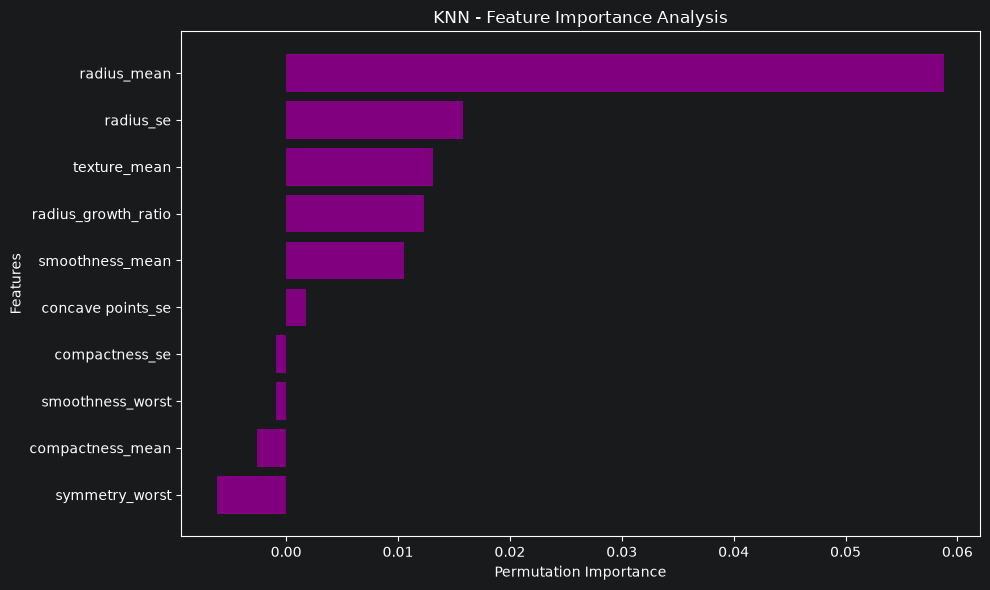

In [9]:
# 1. Permutation Importance Calculation
result = permutation_importance(
    knn_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

importances = result.importances_mean
feature_names = bundle["selected_features"]

# 2. Convert to DataFrame and List
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- KNN Feature Importance Scores ---")
print(feature_imp_df)

# 3. Virtualization
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="purple"
)
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("KNN - Feature Importance Analysis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
# 1. Read the original raw CSV file directly
df = pd.read_csv("../datasets/cancer_data.csv")

# 2. Split into X and y
X = df.drop(
    ["id","diagnosis","Unnamed: 32"], axis=1
)
y = df["diagnosis"]

# 3. Split into Train-Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model Train with Raw Data
knn_raw_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="manhattan",
)
knn_raw_model.fit(X_train_raw, y_train)

# 5. Train Set Performance for Raw Model
y_train_pred_raw = knn_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("      RAW DATA - TRAIN SET PERFORMANCE      ")
print("=" * 40)
print(f"Train Accuracy Rate: {train_accuracy_raw:.4f}\n")
print("Train Classification (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Test Set Performance for Raw Model
y_test_pred_raw = knn_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("      HAM VERİ - TEST SETİ PERFORMANCE       ")
print("=" * 40)
print(f"Test Accuracy Rate: {test_accuracy_raw:.4f}\n")
print("Test Classification (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

      RAW DATA - TRAIN SET PERFORMANCE      
Train Accuracy Rate: 0.9560

Train Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       285
           1       0.97      0.91      0.94       170

    accuracy                           0.96       455
   macro avg       0.96      0.95      0.95       455
weighted avg       0.96      0.96      0.96       455

      HAM VERİ - TEST SETİ PERFORMANCE       
Test Accuracy Rate: 0.9123

Test Classification (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        72
           1       1.00      0.76      0.86        42

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114

